---
title: "Machine Learning"
format:
  html:
    embed-resources: true
    code-fold: true
    toc: true
---

## Overview
  
This tab contains all the information for running Machine Learning on our dataset. Our goal is to predict the political party based on the content of a Reddit post, without having to go through any cleaning, keyword identification or sentiment analysis done in the previous steps. Our hope is that this will be deployable to repeat this project's polling process without being as resource intensive.   

## Reading Clean & Labeled Data

In [ ]:
#initialize session
spark

#import libraries
from azureml.core import Workspace, Dataset, Datastore
from pyspark.sql import functions as F

#read data
subscription_id = '21ff0fc0-dd2c-450d-93b7-96eeb3699b22'
resource_group = 'project-group-11'
workspace_name = 'project-group-11'
workspace = Workspace(subscription_id, resource_group, workspace_name)
datastore = Datastore.get(workspace, "workspaceblobstore")

dataset_submissions = Dataset.Tabular.from_parquet_files(path=(datastore, 'cleandata/submissions_labeled_Jude.parquet'))
dataset_comments = Dataset.Tabular.from_parquet_files(path=(datastore, 'cleandata/comments_labeled_Jude.parquet'))

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 85, 8, Finished, Available, Finished)

Performing interactive authentication. Please follow the instructions on the terminal.
To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code BN33DBN5W to authenticate.
Interactive authentication successfully completed.


**Convert to Spark Dataframe:** 

In [4]:
df_submissions = dataset_submissions.to_spark_dataframe()
df_comments = dataset_comments.to_spark_dataframe()

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 85, 9, Finished, Available, Finished)

In [5]:
df_submissions.head(1)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 85, 10, Finished, Available, Finished)

[Row(id='uirqit', body=" \n\n**Wireless Brain Sensor** **Market Overview:**\xa0\n\nThe study covers the [Wireless Brain Sensor market's ](https://www.maximizemarketresearch.com/market-report/global-wireless-brain-sensor-market/84003/)most recent revenue and market trends. It stresses a market overview, definition, and structure, as well as preventative and pre-planned management. The report focuses on the factors that influence the Wireless Brain Sensor Market, such as gross margin, cost, market share, capacity utilisation, and supply. It also aids in determining the future potential of Wireless Brain Sensor Market in the next years. The report presents a market overview through common subjects that are highlighted with unique data based on the need. This overview aids in making decisions about how to approach the market and comprehending the industry's backdrop.\n\n**Request for free sample:**\xa0\n\n[**https://www.maximizemarketresearch.com/request-sample/84003**](https://www.maximiz

In [9]:
df_comments.head(1)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 14, Finished, Available, Finished)

[Row(id='uirqit', body=" \n\n**Wireless Brain Sensor** **Market Overview:**\xa0\n\nThe study covers the [Wireless Brain Sensor market's ](https://www.maximizemarketresearch.com/market-report/global-wireless-brain-sensor-market/84003/)most recent revenue and market trends. It stresses a market overview, definition, and structure, as well as preventative and pre-planned management. The report focuses on the factors that influence the Wireless Brain Sensor Market, such as gross margin, cost, market share, capacity utilisation, and supply. It also aids in determining the future potential of Wireless Brain Sensor Market in the next years. The report presents a market overview through common subjects that are highlighted with unique data based on the need. This overview aids in making decisions about how to approach the market and comprehending the industry's backdrop.\n\n**Request for free sample:**\xa0\n\n[**https://www.maximizemarketresearch.com/request-sample/84003**](https://www.maximiz

## Stratified Sampling

In order to perform ML, we used a stratified sampling method to grab 100k data points from our clean and labeled dataset. These data points will be well balanced and will be used to train our models.

We decided to only use the body of the post as our single input feature in order to maximize efficiency. Therefore, our ML dataframe once created only contained 2 features: the body of the text of the post, and the assigned party label.  

In [11]:
# Step 1: select specific colums
df_submissions_selected = df_submissions.select("body", "Party")
df_comments_selected = df_comments.select("body", "Party")

# Step 2: combine dataframes
df_combined = df_submissions_selected.union(df_comments_selected)

# Step 3: calculate counts and proportions to sample equal number
class_counts = df_combined.groupBy("Party").count().collect()
total_count = sum(row['count'] for row in class_counts)
desired_per_class = 100000 // len(class_counts)  # Target per class
proportions = {
    row['Party']: min(desired_per_class / row['count'], 1.0) for row in class_counts
}

# Step 4: perform stratified sampling
df_sampled = df_combined.sampleBy("Party", fractions=proportions, seed=42)

# Step 5: ensure the resulting dataset has exactly 100k rows
df_sampled_limited = df_sampled.limit(100000)

# Step 6: double check
df_sampled_limited.groupBy("Party").count().show()

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 16, Finished, Available, Finished)

+----------+-----+
|     Party|count|
+----------+-----+
|  No Party|33224|
|Republican|33283|
|  Democrat|33493|
+----------+-----+



In [13]:
# Show first 5 rows
df_sampled_limited.show(5)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 18, Finished, Available, Finished)

+--------------------+----------+
|                body|     Party|
+--------------------+----------+
| A deluded but aw...|Republican|
|I've been thinkin...|  No Party|
| \n\n# Topic: Mar...|  Democrat|
| \n\nGood morning...|  Democrat|
|\nWelcome to /r/L...|Republican|
+--------------------+----------+
only showing top 5 rows



**Now that we had our well balanced dataset, we could move on to ML:**

## Machine Learning

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 40, Finished, Available, Finished)

**Repartitioning the data and converting to Pandas in order to proceed with our ML algorithms:**

In [28]:
df_sampled_limited = df_sampled_limited.repartition(100)  # Adjust the number of partitions
df_sampled_limited_pd = df_sampled_limited.toPandas()

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 33, Finished, Available, Finished)

### Vectorization and Encoding

**Before training our model, the text data from the body input feature needed to be vectorized, while the Party label feature needed to be encoded:** 

In [30]:
# text vectorization
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df_sampled_limited_pd['body'])  # 'body' column as features

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 35, Finished, Available, Finished)

In [36]:
# encode Party label as numeric labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_sampled_limited_pd['Party'])  # Encode 'Democrat', 'No Party', 'Republican' to 0, 1, 2

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 41, Finished, Available, Finished)

### Model 1: Random Forest

As our first classifier, we selected Random Forest (RF). As an ensemble method, the RF combines multiple decision trees to improve predictive accuracy and robustness, making it well-suited for handling noisy text data.

In [37]:
# build and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# make predictions
rf_predictions = rf_model.predict(X_test)

# evaluate
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_confusion = confusion_matrix(y_test, rf_predictions)
rf_classification_report = classification_report(y_test, rf_predictions)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 42, Finished, Available, Finished)

In [38]:
print("Random Forest - Accuracy: ", rf_accuracy)
print("Random Forest - Classification Report:\n", rf_classification_report)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 43, Finished, Available, Finished)

Random Forest - Accuracy:  0.67935
Random Forest - Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.56      0.64      6700
           1       0.65      0.94      0.77      6645
           2       0.67      0.54      0.60      6655

    accuracy                           0.68     20000
   macro avg       0.69      0.68      0.67     20000
weighted avg       0.69      0.68      0.67     20000



### Model 2: XGBoost

As our second model, we selected the XGBoost, which is a gradient boosted technique that offers efficient learning and fine-tuning capabilities, enabling it to capture nuanced patterns in text.

In [39]:
# build and train the XGBoost model
xgb_model = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# make predictions 
xgb_predictions = xgb_model.predict(X_test)

# evaluate
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_confusion = confusion_matrix(y_test, xgb_predictions)
xgb_classification_report = classification_report(y_test, xgb_predictions)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 44, Finished, Available, Finished)

In [40]:
print("XGBoost - Accuracy: ", xgb_accuracy)
print("XGBoost - Classification Report:\n", xgb_classification_report)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 45, Finished, Available, Finished)

XGBoost - Accuracy:  0.8271
XGBoost - Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.77      0.78      6700
           1       0.89      0.98      0.93      6645
           2       0.80      0.73      0.76      6655

    accuracy                           0.83     20000
   macro avg       0.82      0.83      0.82     20000
weighted avg       0.82      0.83      0.82     20000



**Finally, we plotted the confusion matrices for both models:**

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 46, Finished, Available, Finished)

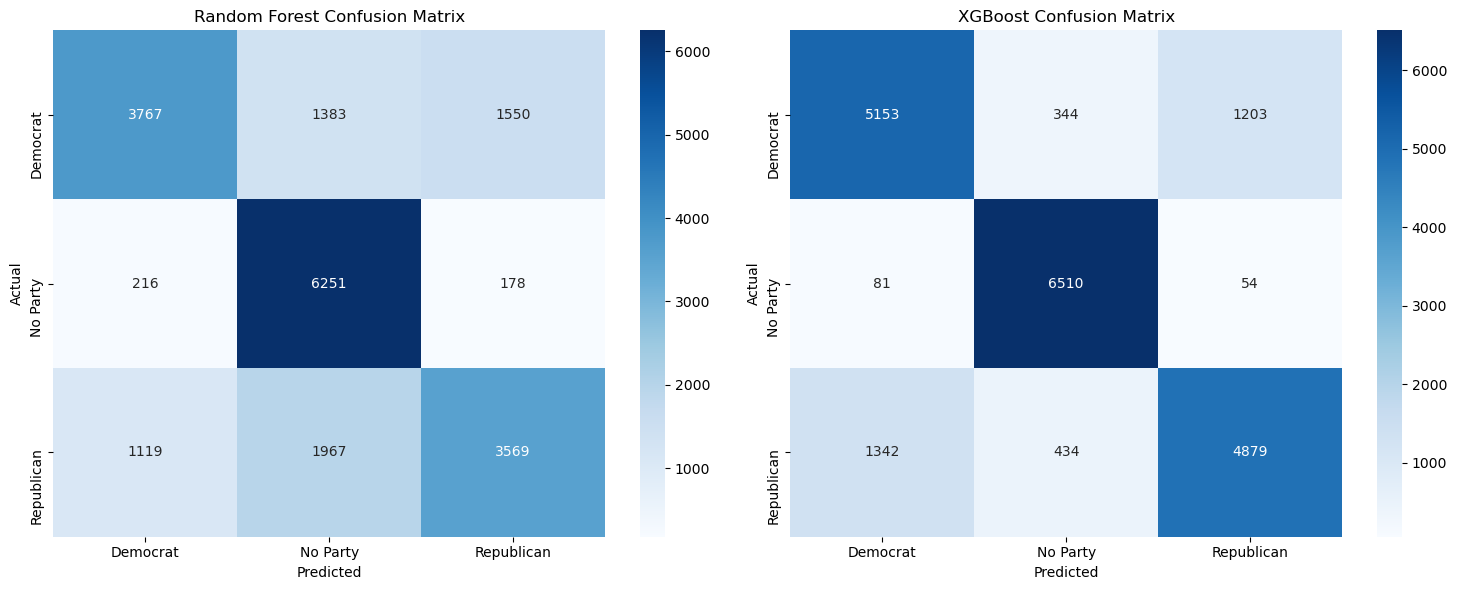

In [41]:
# creating plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RF Confusion Matrix
sns.heatmap(rf_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[0])
axes[0].set_title("Random Forest Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# xgb Confusion Matrix
sns.heatmap(xgb_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[1])
axes[1].set_title("XGBoost Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Model Optimization

The XGB model shows a higher accuracy of 83%, compared to our Random Forest model with accuracy of 68%. However, we haven't optimized the models yet.  

The following section shows how we would optimize the models prior to selecting which model performs best.

**Please note** that the cells below have not been run on this notebook or as a job due to resource constraints, as we have already used the majority of our allocated funding in Azure. In theory, we would be using the Random Search function to select the best hyperparameters for each model, as shown below.

We feel that the XGB model, while not optimized, still provides a pretty good accuracy for predicting the political party based on the body of a post.

### Random Forest Optimization

In [42]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 47, Finished, Available, Finished)

In [43]:
# Random Forest hyperparameter space
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=50,  # Number of combinations to try
    scoring='accuracy',
    cv=3,  # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# Step 3: Fit the models using RandomizedSearchCV
print("Tuning Random Forest...")
rf_random.fit(X_train, y_train)

# Step 4: Evaluate the best models
print("Best parameters for Random Forest:", rf_random.best_params_)

StatementMeta(16fd2129-cd11-4016-9021-0a19ae621014, 81, 48, Cancelled, Cancelling, Cancelling)

Tuning Random Forest...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time= 2.3min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time= 2.2min
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time= 2.2min


In [ ]:
# Get the best estimators
best_rf = rf_random.best_estimator_
rf_predictions = best_rf.predict(X_test)

# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_classification_report = classification_report(y_test, rf_predictions)
print(f"Optimized Random Forest Accuracy: {rf_accuracy}")
print("Random Forest Classification Report:\n", rf_classification_report)

### XGBoost Optimization

In [ ]:
# XGBoost hyperparameter space
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# XGBoost
xgb_random = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=50,  # Number of combinations to try
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Tuning XGBoost...")
xgb_random.fit(X_train, y_train)

print("Best parameters for XGBoost:", xgb_random.best_params_)

In [ ]:
best_xgb = xgb_random.best_estimator_
xgb_predictions = best_xgb.predict(X_test)

# Evaluate XGBoost
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_classification_report = classification_report(y_test, xgb_predictions)
print(f"Optimized XGBoost Accuracy: {xgb_accuracy}")
print("XGBoost Classification Report:\n", xgb_classification_report)